# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 2 aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos.

## Importando bibliotecas e dados

In [19]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
import pandas as pd
from statistics import mode, median, StatisticsError
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_25062025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_25062025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_25062025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_25062025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_25062025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_25062025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_25062025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_25062025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_25062025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3886 entries, 0 to 3885
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPF                        3886 non-null   object 
 1   Nome                       3886 non-null   object 
 2   Turma                      3886 non-null   object 
 3   Data de início             3886 non-null   object 
 4   Alfabetizador              3886 non-null   object 
 5   Coordenador                3886 non-null   object 
 6   Qtde presença              3886 non-null   int64  
 7   Qtde ausência              3886 non-null   int64  
 8   Atividade - Entrada        3783 non-null   object 
 9   Atividade - Formativa 1    3704 non-null   object 
 10  Atividade - Formativa 2    3171 non-null   object 
 11  Atividade - Formativa 3    1630 non-null   object 
 12  Atividade - Formativa 4    252 non-null    object 
 13  Atividade - Saída          0 non-nu

## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [20]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]
df_relatorios_formativa4.columns = [to_snake_case(col) for col in df_relatorios_formativa4.columns]
df_relatorios_somativa.columns = [to_snake_case(col) for col in df_relatorios_somativa.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_diagnostica.info())


Vamos verificar número de turmas que ainda não iniciaram e criar uma lista de código de turmas que ainda não iniciaram para serem retiradas de todos os dataframes.

In [21]:
# Criando lista de turmas que não iniciaram
turmas_nao_iniciadas = df_turmas[df_turmas['data_inicio'] == 'Não iniciado']['turma'].to_list()

print(f'Número de turmas a serem retiradas: {len(turmas_nao_iniciadas)}')
print(f'Códigos das turmas a serem retiradas: {turmas_nao_iniciadas}')

Número de turmas a serem retiradas: 32
Códigos das turmas a serem retiradas: ['TURMA-P0000028-0001', 'TURMA-28018389-0001', 'TURMA-28018389-0002', 'TURMA-28018389-0003', 'TURMA-28018389-0006', 'TURMA-28018389-0009', 'TURMA-28018389-0005', 'TURMA-28018575-0014', 'TURMA-28010132-0003', 'TURMA-28010132-0004', 'TURMA-28031911-0003', 'TURMA-28031911-0004', 'TURMA-28020766-0001', 'TURMA-28020766-0002', 'TURMA-28020472-0007', 'TURMA-28020472-0004', 'TURMA-28020472-0005', 'TURMA-28020472-0006', 'TURMA-28020480-0001', 'TURMA-28021223-0010', 'TURMA-28021223-0013', 'TURMA-28020529-0003', 'TURMA-28020529-0004', 'TURMA-28018508-0008', 'TURMA-28018508-0009', 'TURMA-28018508-0007', 'TURMA-28009410-0003', 'TURMA-28009983-0001', 'TURMA-28009983-0002', 'TURMA-28009983-0003', 'TURMA-28009983-0004', 'TURMA-P0000013-0001']


Temos um total de 35 que devem ser retiradas dos dfs, mas somente 32 foram detectadas com status de "Não iniciado". Assim, vamos criar uma segunda lista com as 3 turmas faltantes, adicionar na lista retirar_turmas e, de fato, retirar os dados dessas turmas dos dfs.

In [22]:
# Lista de 3 turmas que precisam também precisam ser retiradas
retirar_turmas_adicionais = [
    'TURMA-28020766-0004',
    'TURMA-28020766-0012',
    'TURMA-28020421-0004',
    'TURMA-28020804-0003'
]

# Inclusão na lista de turmas para retirada
retirar_turmas = list(set(turmas_nao_iniciadas + retirar_turmas_adicionais))

# Imprimindo resultado da lista completa
print(f'Número de turmas a serem retiradas: {len(retirar_turmas)}')
print(f'Códigos das turmas a serem retiradas: {retirar_turmas}')

Número de turmas a serem retiradas: 36
Códigos das turmas a serem retiradas: ['TURMA-28020766-0012', 'TURMA-28020766-0004', 'TURMA-28018575-0014', 'TURMA-28009983-0002', 'TURMA-28018389-0009', 'TURMA-28018389-0001', 'TURMA-28018389-0005', 'TURMA-28020766-0002', 'TURMA-28020472-0006', 'TURMA-28018389-0006', 'TURMA-28020529-0004', 'TURMA-28020529-0003', 'TURMA-28009983-0004', 'TURMA-28020766-0001', 'TURMA-28009410-0003', 'TURMA-28010132-0004', 'TURMA-28020480-0001', 'TURMA-28010132-0003', 'TURMA-28018508-0008', 'TURMA-28020472-0004', 'TURMA-28031911-0003', 'TURMA-28021223-0013', 'TURMA-28018508-0007', 'TURMA-28020421-0004', 'TURMA-28018389-0002', 'TURMA-28009983-0001', 'TURMA-28031911-0004', 'TURMA-28020472-0005', 'TURMA-28021223-0010', 'TURMA-28020804-0003', 'TURMA-28018389-0003', 'TURMA-28018508-0009', 'TURMA-P0000013-0001', 'TURMA-P0000028-0001', 'TURMA-28020472-0007', 'TURMA-28009983-0003']


Nota: Observa-se que um total de 36 foram retiradas. Isso porque foi observado que a turma de código TURMA-P0000028-0001, em São Cristóvão, ainda não havia iniciado. Portanto, também foi retirada da análise, apesar de não está na lista de 35 turmas que serão avaliadas posteriormente.

Em seguida, vamos retirar os dados das turmas de todos os dataframes.

In [23]:
# Função para retirar turmas
def remover_turmas(df, coluna_turma='turma', turmas_para_remover=None):
    """
    Remove linhas do DataFrame onde a coluna de turma está na lista de turmas para remover.
    
    Parâmetros:
    - df: DataFrame do pandas
    - coluna_turma: Nome da coluna que contém os códigos das turmas (padrão: 'turma')
    - turmas_para_remover: Lista de códigos de turmas a serem removidas
    
    Retorna:
    - DataFrame com as turmas removidas
    """
    if turmas_para_remover is None:
        return df
    
    # Verifica se a coluna existe no DataFrame
    if coluna_turma not in df.columns:
        print(f"Aviso: Coluna '{coluna_turma}' não encontrada no DataFrame.")
        return df
    
    # Filtra o DataFrame mantendo apenas as linhas onde a turma não está na lista de remoção
    df_filtrado = df[~df[coluna_turma].isin(turmas_para_remover)].copy()
    
    return df_filtrado

# Removendo turmas dos DataFrames
df_cadastro = remover_turmas(df_cadastro, 'turma', retirar_turmas)
df_turmas = remover_turmas(df_turmas, 'turma', retirar_turmas)
df_registros = remover_turmas(df_registros, 'turma', retirar_turmas)
df_relatorios_diagnostica = remover_turmas(df_relatorios_diagnostica, 'turma', retirar_turmas)
df_relatorios_formativa1 = remover_turmas(df_relatorios_formativa1, 'turma', retirar_turmas)
df_relatorios_formativa2 = remover_turmas(df_relatorios_formativa2, 'turma', retirar_turmas)
df_relatorios_formativa3 = remover_turmas(df_relatorios_formativa3, 'turma', retirar_turmas)
df_relatorios_formativa4 = remover_turmas(df_relatorios_formativa4, 'turma', retirar_turmas)
df_relatorios_somativa = remover_turmas(df_relatorios_somativa, 'turma', retirar_turmas)

#df_registros[df_registros['municipio'] == 'Aracaju']['turma'].nunique()


Agora vamos alterar as colunas com datas para o formato correto.

In [24]:
# Transformando colunas de data para o tipo datetime
df_cadastro['data_de_inicio'] = pd.to_datetime(df_cadastro["data_de_inicio"], format="%d/%m/%Y")
df_turmas['data_inicio'] = pd.to_datetime(df_turmas["data_inicio"], format="%d/%m/%Y")
df_relatorios_diagnostica['data_de_lancamento'] = pd.to_datetime(df_relatorios_diagnostica["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa1['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa1["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa2['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa2["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa3['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa3["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa4['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa4["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_somativa['data_de_lancamento'] = pd.to_datetime(df_relatorios_somativa["data_de_lancamento"], format="%d/%m/%Y")

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_relatorios_diagnostica.info())
#print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa3.info())

Com as datas nos moldes corretos, agora vamos criar dfs separados para cada avaliação realizada.

In [25]:
# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA']


## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [26]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")


Número total de alunos estudando: 3821
Número total de turmas iniciadas: 282
Número médio de alunos por turma: 13.55


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [27]:
# Criando lista de turmas em cada unidade
ls_turmas_somativa = set(df_registros_form_4['turma'].unique().tolist())
ls_turmas_unid_4 = set(df_registros_form_3['turma'].unique().tolist()) - ls_turmas_somativa
ls_turmas_unid_3 = set(df_registros_form_2['turma'].unique().tolist()) - ls_turmas_unid_4 - ls_turmas_somativa
ls_turmas_unid_2 = set(df_registros_form_1['turma'].unique().tolist()) - ls_turmas_unid_3 - ls_turmas_unid_4 - ls_turmas_somativa
ls_turmas_unid_1 = set(df_registros_diag['turma'].unique().tolist()) - ls_turmas_unid_2 - ls_turmas_unid_3 - ls_turmas_unid_4 - ls_turmas_somativa

# Primeiro criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade


Checando total de turmas: 276


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,total_turmas
0,Aquidabã,0,0,3,0,0,3
1,Aracaju,4,10,21,13,0,48
2,Areia Branca,0,0,0,2,0,2
3,Boquim,0,1,4,1,0,6
4,Canindé de São Francisco,0,0,0,5,0,5
5,Capela,0,0,4,5,2,11
6,Carira,0,0,1,2,0,3
7,Cristinápolis,0,1,3,0,0,4
8,Estância,0,1,0,2,0,3
9,Frei Paulo,0,0,2,0,0,2


In [28]:
ls_total = list(
    ls_turmas_somativa 
    | ls_turmas_unid_1 
    | ls_turmas_unid_2 
    | ls_turmas_unid_3 
    | ls_turmas_unid_4
)

turmas_desaparecidas = set(df_turmas['turma'].unique().tolist()) - set(ls_total)
turmas_desaparecidas


{'TURMA-28018575-0013',
 'TURMA-28018796-0002',
 'TURMA-28026667-0026',
 'TURMA-P0000004-0001',
 'TURMA-P0000021-0003'}

/tmp/ipykernel_69588/3860754746.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),


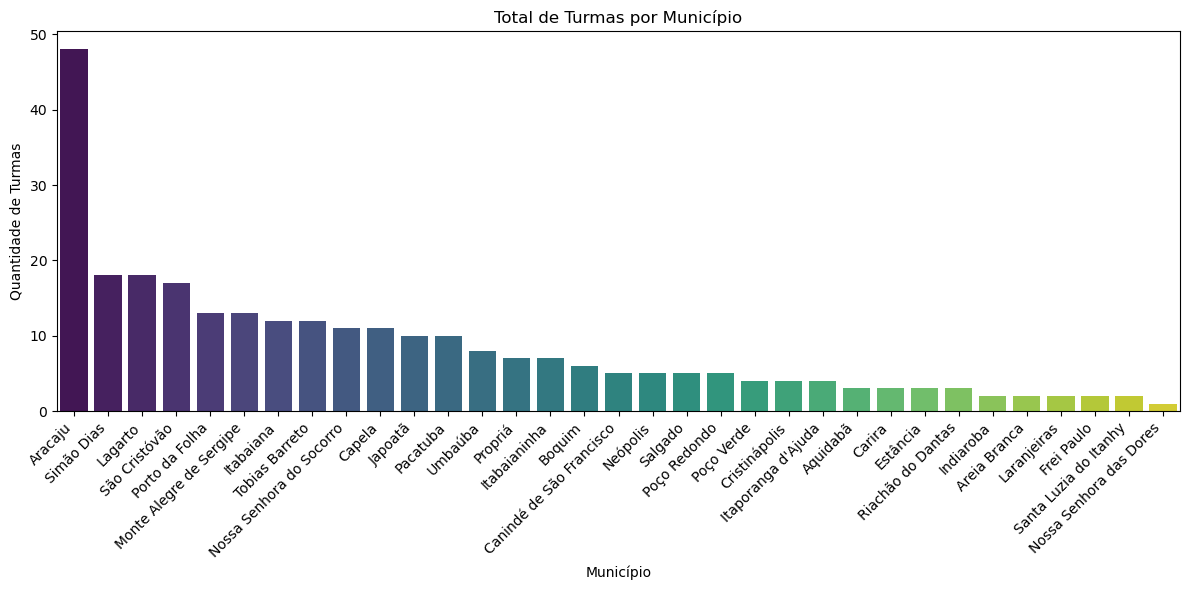

In [29]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_22 = "Data_files/graficos_relatorio_2.2"
os.makedirs(output_dir_relatorio_22, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_22}/total_por_municipio.png', dpi=300)
plt.show()

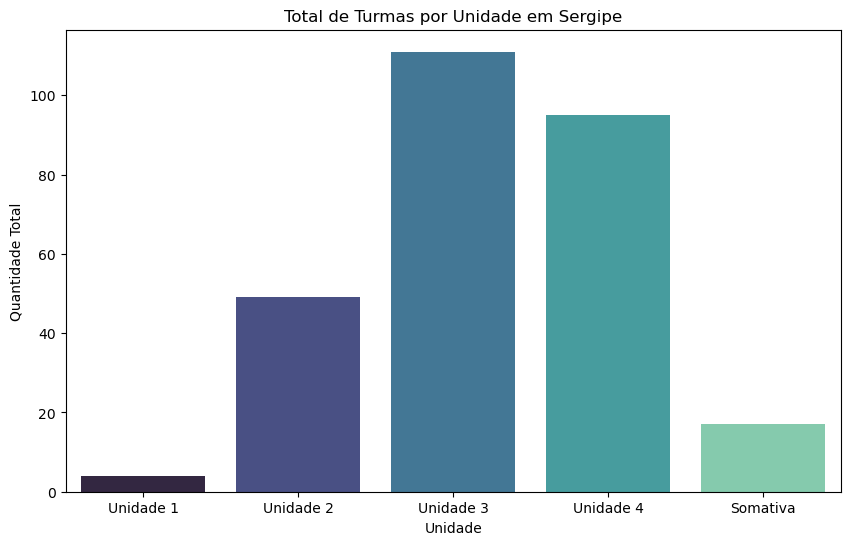

In [30]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_22}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

In [31]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_22}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [32]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2 ou 3)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)
df_producao_escrita = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)

# Removendo uma turma que não há dados
linhas_a_remover = df_analise_linguistica[
    df_analise_linguistica['turma'].isin(['TURMA-P0000002-0003', 'TURMA-28003365-0003'])
].index

df_analise_linguistica = df_analise_linguistica.drop(linhas_a_remover)

# Contando número total de alunos por turma com base na Formativa 1
df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_producao_escrita['total_alunos_form_3'] = df_producao_escrita[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
df_producao_escrita['total_alunos_form_4'] = df_producao_escrita[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)

# Retirando turmas que não contém dados
df_analise_linguistica = df_analise_linguistica[
    df_analise_linguistica['turma'].isin(
        list(ls_turmas_unid_3) + 
        list(ls_turmas_unid_4) + 
        list(ls_turmas_somativa))]
#df_analise_linguistica = df_analise_linguistica[df_analise_linguistica['turma'].isin(ls_turmas_unid_3)]
df_oralidade_leitura_13 = df_oralidade_leitura_13[df_oralidade_leitura_13['turma'].isin(ls_turmas_unid_4)]
df_oralidade_leitura_14 = df_oralidade_leitura_14[df_oralidade_leitura_14['turma'].isin(ls_turmas_somativa)]
df_oralidade_leitura_34 = df_oralidade_leitura_34[df_oralidade_leitura_34['turma'].isin(ls_turmas_somativa)]
df_producao_escrita = df_producao_escrita[df_producao_escrita['turma'].isin(ls_turmas_somativa)]


In [33]:
# Informações de Formativa 1 de municípios

df_valores_form_1 = moda_form_1[moda_form_1['turma'].isin(ls_turmas_unid_2)].reset_index(drop=True)

count_valores_form_1 = df_valores_form_1.groupby(['municipio', 'linguagem', 'nivel']).size().unstack(fill_value=0)

count_valores_form_1['total'] = count_valores_form_1[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)

moda_form_1.head()

/tmp/ipykernel_69588/867261129.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_valores_form_1 = df_valores_form_1.groupby(['municipio', 'linguagem', 'nivel']).size().unstack(fill_value=0)


,cpf,nome,turma,municipio,linguagem,nivel
0,012.479.683-40,Dr. Henry Gabriel Brito,TURMA-28022394-0004,Cristinápolis,Análise linguística,Nível 2
1,012.479.683-40,Dr. Henry Gabriel Brito,TURMA-28022394-0004,Cristinápolis,Oralidade e leitura,Nível 3
2,012.536.974-34,Ana Clara Martins,TURMA-28008804-0005,Poço Verde,Análise linguística,Nível 2
3,012.536.974-34,Ana Clara Martins,TURMA-28008804-0005,Poço Verde,Oralidade e leitura,Nível 2
4,012.637.498-87,Isabel Silveira,TURMA-28031547-0002,Itabaiana,Análise linguística,Nível 3


In [34]:
# Lista de municípios únicos
municipios_form_1 = moda_form_1['municipio'].unique()


# Criando loop para gerar gráficos
for municipio in municipios_form_1:
    # Filtrar dados para o município atual
    df_municipio = moda_form_1[moda_form_1['municipio'] == municipio]
    
    # Agrupar dados (igual ao seu processamento original)
    df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
    df_analise['total'] = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
    
    # Agrupado dados em porcentagem
    porcentagem_nivel = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise['total'], axis=0) * 100    
    
    # Preparar dados no formato longo
    df_long = porcentagem_nivel.reset_index().melt(
        id_vars='linguagem',
        var_name='nivel',
        value_name='contagem'
    )
    
    # Quebra de rótulos específicos (igual ao anterior)
    rotulos_quebrados = []
    for rotulo in porcentagem_nivel.index:
        if rotulo == "Análise linguística":
            rotulo = "Análise\nlinguística"
        elif rotulo == "Oralidade e leitura":
            rotulo = "Oralidade\ne leitura"
        rotulos_quebrados.append(rotulo)
    
    # Criar figura
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=df_long,
        x='linguagem',
        y='contagem',
        hue='nivel',
        palette='rocket',
        edgecolor='black',
        width=0.7
    )
    
    # Formatação do gráfico
    ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)
    plt.title(f'Distribuição por Nível em Formativa 1\nMunicípio: {municipio}', fontsize=16, pad=20)
    plt.xlabel('Linguagem', fontsize=14)
    plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
    plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salvar o gráfico
    nome_arquivo = f'grafico_form_1_{municipio.lower().replace(" ", "_")}.png'
    caminho_completo = os.path.join(output_dir_relatorio_22, nome_arquivo)
    
    plt.savefig(
        caminho_completo,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    
    plt.close()  # Fecha a figura para liberar memória
    
    print(f'Gráfico salvo: {caminho_completo}')

print("Processo concluído! Todos os gráficos foram gerados.")

/tmp/ipykernel_69588/3180577097.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69588/3180577097.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.2/grafico_form_1_cristinápolis.png


/tmp/ipykernel_69588/3180577097.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69588/3180577097.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.2/grafico_form_1_poço_verde.png


/tmp/ipykernel_69588/3180577097.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69588/3180577097.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


...

Gráfico salvo: Data_files/graficos_relatorio_2.2/grafico_form_1_laranjeiras.png


/tmp/ipykernel_69588/3180577097.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69588/3180577097.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.2/grafico_form_1_boquim.png


/tmp/ipykernel_69588/3180577097.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69588/3180577097.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.2/grafico_form_1_nossa_senhora_das_dores.png
Processo concluído! Todos os gráficos foram gerados.


#### Teste estatístico


=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 3823.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 2:
Estatística = 7581.500, p-valor = 0.0002
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 3:
Estatística = 3662.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 0.000, p-valor = 0.0625
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Níve

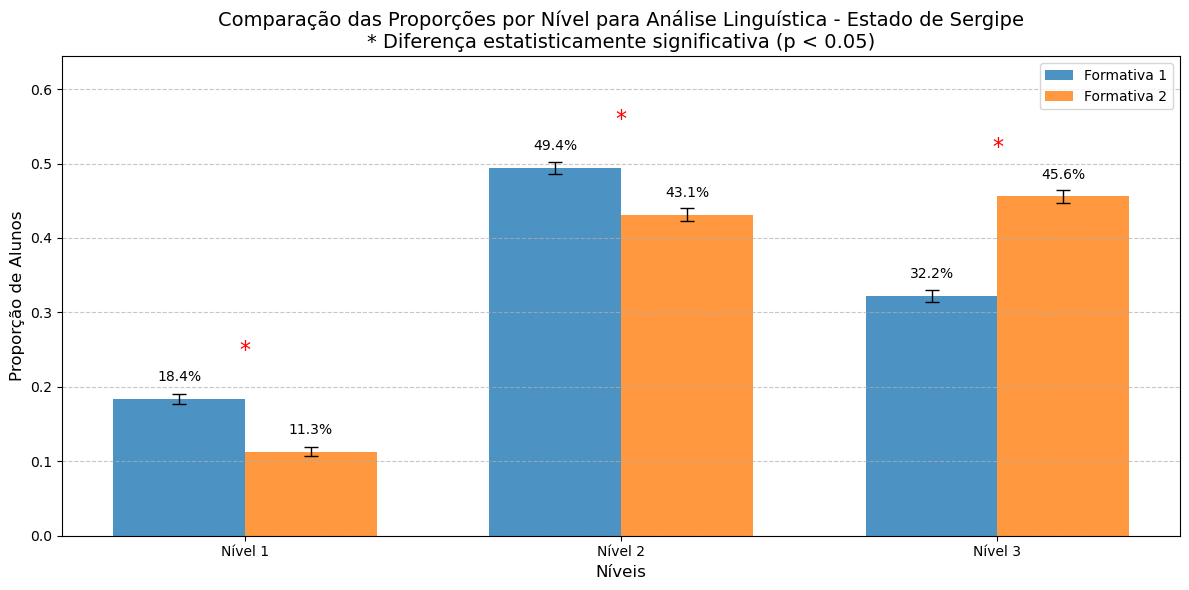

In [35]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                       df_analise_linguistica[f'prop_form_2_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_analise_linguistica[f'prop_form_2_{nivel}'] - df_analise_linguistica[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===\n")

for municipio in df_analise_linguistica['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_analise_linguistica[df_analise_linguistica['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_2_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_2_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ANÁLISE LINGUÍSTICA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_analise_linguistica['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_analise_linguistica['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_analise_linguistica['form_1_Nível 3'].sum(),
    'form_2_Nível 1': df_analise_linguistica['form_2_Nível 1'].sum(),
    'form_2_Nível 2': df_analise_linguistica['form_2_Nível 2'].sum(),
    'form_2_Nível 3': df_analise_linguistica['form_2_Nível 3'].sum(),
    'total_form_1': df_analise_linguistica['total_alunos_form_1'].sum(),
    'total_form_2': df_analise_linguistica['total_alunos_form_2'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_2:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_2_Nível 1'], totais_estado['form_2_Nível 2'], totais_estado['form_2_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_2 = [totais_estado['form_2_Nível 1']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 2']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 3']/totais_estado['total_form_2']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_2 = [calc_erro_proporcao(p, totais_estado['total_form_2']) for p in prop_form_2]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_2, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                            df_analise_linguistica[f'prop_form_2_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Análise Linguística - Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_2) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_analise_linguistica_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [36]:
# Testando Análise Linguística e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_2_Nível 1': group['form_2_Nível 1'].sum(),
            'form_2_Nível 2': group['form_2_Nível 2'].sum(),
            'form_2_Nível 3': group['form_2_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_2': group['total_alunos_form_2'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_2 = [
            totais_municipio['form_2_Nível 1']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 2']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 3']/totais_municipio['total_form_2']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_2']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_2_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Análise Linguística - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_analise_linguistica_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_analise_linguistica, output_dir_relatorio_22)

Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Aquidabã.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Boquim.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Cristinápolis.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguistica_Estância.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_analise_linguis

Agora vamos realizar o mesmo teste estatístico para Oralidade e Leitura


=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 1 E 3) PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 805.000, p-valor = 0.0017
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 2:
Estatística = 1336.500, p-valor = 0.0097
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 3:
Estatística = 998.500, p-valor = 0.0002
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 1 E 3) ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 1.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05

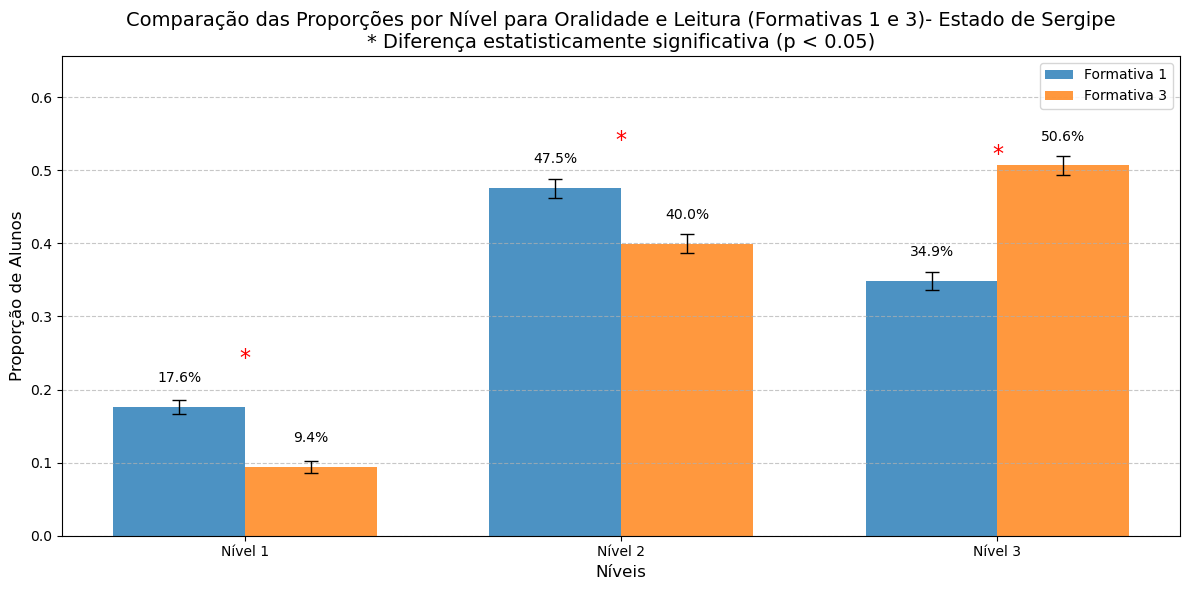

In [37]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_oralidade_leitura_13[f'prop_form_1_{nivel}'] = df_oralidade_leitura_13[f'form_1_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_1']
    df_oralidade_leitura_13[f'prop_form_3_{nivel}'] = df_oralidade_leitura_13[f'form_3_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_3']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 1 E 3) PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_oralidade_leitura_13[f'prop_form_1_{nivel}'], 
                       df_oralidade_leitura_13[f'prop_form_3_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_oralidade_leitura_13[f'prop_form_3_{nivel}'] - df_oralidade_leitura_13[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 1 E 3) ===\n")

for municipio in df_oralidade_leitura_13['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_oralidade_leitura_13[df_oralidade_leitura_13['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_3_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_3_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ORALIDADE E LEITURA (FORMATIVAS 1 E 3) (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_oralidade_leitura_13['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_oralidade_leitura_13['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_oralidade_leitura_13['form_1_Nível 3'].sum(),
    'form_3_Nível 1': df_oralidade_leitura_13['form_3_Nível 1'].sum(),
    'form_3_Nível 2': df_oralidade_leitura_13['form_3_Nível 2'].sum(),
    'form_3_Nível 3': df_oralidade_leitura_13['form_3_Nível 3'].sum(),
    'total_form_1': df_oralidade_leitura_13['total_alunos_form_1'].sum(),
    'total_form_3': df_oralidade_leitura_13['total_alunos_form_3'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_3_Nível 1'], totais_estado['form_3_Nível 2'], totais_estado['form_3_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_3 = [totais_estado['form_3_Nível 1']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 2']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 3']/totais_estado['total_form_3']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_3 = [calc_erro_proporcao(p, totais_estado['total_form_3']) for p in prop_form_3]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_3, bar_width, label='Formativa 3', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_3, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_oralidade_leitura_13[f'prop_form_1_{nivel}'], 
                            df_oralidade_leitura_13[f'prop_form_3_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 1 e 3)- Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_3) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_oralidade_leitura_13_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()



=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 1 E 4) PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 3.000, p-valor = 0.0076
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 2:
Estatística = 29.500, p-valor = 0.0832
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.
---
Teste de Wilcoxon para Nível 3:
Estatística = 15.500, p-valor = 0.0114
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 1 E 4) ===


Município: Monte Alegre de Sergipe

Nível 1:
Estatística = 1.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 2:
Estatística = 1.000, p-valor = 0.50

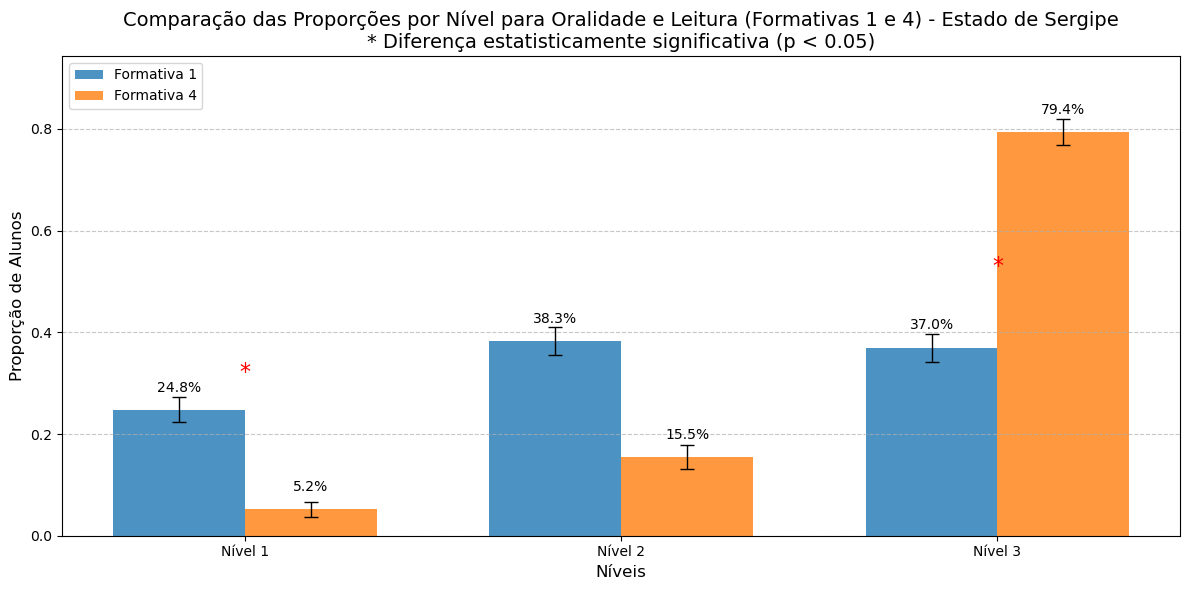

In [38]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_oralidade_leitura_14[f'prop_form_1_{nivel}'] = df_oralidade_leitura_14[f'form_1_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_1']
    df_oralidade_leitura_14[f'prop_form_4_{nivel}'] = df_oralidade_leitura_14[f'form_4_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 1 E 4) PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_oralidade_leitura_14[f'prop_form_1_{nivel}'], 
                       df_oralidade_leitura_14[f'prop_form_4_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_oralidade_leitura_14[f'prop_form_4_{nivel}'] - df_oralidade_leitura_14[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 1 E 4) ===\n")

for municipio in df_oralidade_leitura_14['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_oralidade_leitura_14[df_oralidade_leitura_14['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_4_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_4_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ORALIDADE E LEITURA (FORMATIVAS 1 E 4) (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_oralidade_leitura_14['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_oralidade_leitura_14['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_oralidade_leitura_14['form_1_Nível 3'].sum(),
    'form_4_Nível 1': df_oralidade_leitura_14['form_4_Nível 1'].sum(),
    'form_4_Nível 2': df_oralidade_leitura_14['form_4_Nível 2'].sum(),
    'form_4_Nível 3': df_oralidade_leitura_14['form_4_Nível 3'].sum(),
    'total_form_1': df_oralidade_leitura_14['total_alunos_form_1'].sum(),
    'total_form_4': df_oralidade_leitura_14['total_alunos_form_4'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_4:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_4_Nível 1'], totais_estado['form_4_Nível 2'], totais_estado['form_4_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_4 = [totais_estado['form_4_Nível 1']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 2']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 3']/totais_estado['total_form_4']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_4 = [calc_erro_proporcao(p, totais_estado['total_form_4']) for p in prop_form_4]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_4, bar_width, label='Formativa 4', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_4, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_oralidade_leitura_14[f'prop_form_1_{nivel}'], 
                            df_oralidade_leitura_14[f'prop_form_4_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 1 e 4) - Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_4) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_oralidade_leitura_14_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 3 E 4) PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 6.000, p-valor = 0.6858
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 1 entre os testes.
---
Teste de Wilcoxon para Nível 2:
Estatística = 8.000, p-valor = 0.0052
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 3:
Estatística = 11.000, p-valor = 0.0092
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 3 E 4) ===


Município: Monte Alegre de Sergipe

Nível 1:
Estatística = 1.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 2:
Estatística = 0.000, p-valor = 0.250

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


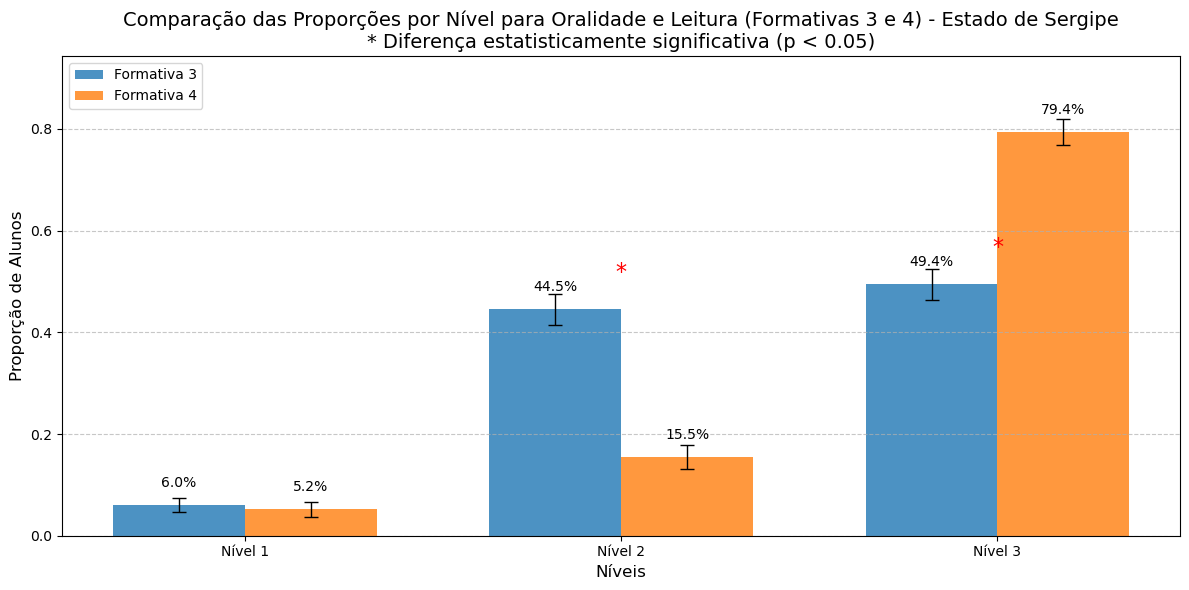

In [39]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_oralidade_leitura_34[f'prop_form_3_{nivel}'] = df_oralidade_leitura_34[f'form_3_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_3']
    df_oralidade_leitura_34[f'prop_form_4_{nivel}'] = df_oralidade_leitura_34[f'form_4_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_4']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA (FORMATIVAS 3 E 4) PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_oralidade_leitura_34[f'prop_form_3_{nivel}'], 
                       df_oralidade_leitura_34[f'prop_form_4_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_oralidade_leitura_34[f'prop_form_4_{nivel}'] - df_oralidade_leitura_34[f'prop_form_3_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO (FORMATIVAS 3 E 4) ===\n")

for municipio in df_oralidade_leitura_34['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_oralidade_leitura_34[df_oralidade_leitura_34['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_3_{nivel}'], 
                           df_municipio[f'prop_form_4_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_4_{nivel}'] - df_municipio[f'prop_form_3_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ORALIDADE E LEITURA (FORMATIVAS 3 E 4) (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_3_Nível 1': df_oralidade_leitura_34['form_3_Nível 1'].sum(),
    'form_3_Nível 2': df_oralidade_leitura_34['form_3_Nível 2'].sum(),
    'form_3_Nível 3': df_oralidade_leitura_34['form_3_Nível 3'].sum(),
    'form_4_Nível 1': df_oralidade_leitura_34['form_4_Nível 1'].sum(),
    'form_4_Nível 2': df_oralidade_leitura_34['form_4_Nível 2'].sum(),
    'form_4_Nível 3': df_oralidade_leitura_34['form_4_Nível 3'].sum(),
    'total_form_3': df_oralidade_leitura_34['total_alunos_form_3'].sum(),
    'total_form_4': df_oralidade_leitura_34['total_alunos_form_4'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_3 e form_4:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_3_Nível 1'], totais_estado['form_3_Nível 2'], totais_estado['form_3_Nível 3']],
    [totais_estado['form_4_Nível 1'], totais_estado['form_4_Nível 2'], totais_estado['form_4_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_3 = [totais_estado['form_3_Nível 1']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 2']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 3']/totais_estado['total_form_3']]

prop_form_4 = [totais_estado['form_4_Nível 1']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 2']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 3']/totais_estado['total_form_4']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_3 = [calc_erro_proporcao(p, totais_estado['total_form_3']) for p in prop_form_3]
erro_form_4 = [calc_erro_proporcao(p, totais_estado['total_form_4']) for p in prop_form_4]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_3, bar_width, label='Formativa 3', alpha=0.8, color='#1f77b4',
               yerr=erro_form_3, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_4, bar_width, label='Formativa 4', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_4, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_oralidade_leitura_34[f'prop_form_3_{nivel}'], 
                            df_oralidade_leitura_34[f'prop_form_4_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_3[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 3 e 4) - Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_3 + prop_form_4) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_oralidade_leitura_34_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [40]:
# Testando Oralidade e Leitura (Formativas 1 e 3) e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_3_Nível 1': group['form_3_Nível 1'].sum(),
            'form_3_Nível 2': group['form_3_Nível 2'].sum(),
            'form_3_Nível 3': group['form_3_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_3': group['total_alunos_form_3'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_3 = [
            totais_municipio['form_3_Nível 1']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 2']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 3']/totais_municipio['total_form_3']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_3']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 3', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_3_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 1 e 3) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_oralidade_leitura_13_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura_13, output_dir_relatorio_22)

Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Boquim.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Estância.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Indiaroba.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_13_Itabaiana.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade

In [41]:
# Testando Oralidade e Leitura (Formativas 1 e 4) e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_4_Nível 1': group['form_4_Nível 1'].sum(),
            'form_4_Nível 2': group['form_4_Nível 2'].sum(),
            'form_4_Nível 3': group['form_4_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_4': group['total_alunos_form_4'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_4 = [
            totais_municipio['form_4_Nível 1']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 2']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 3']/totais_municipio['total_form_4']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_4']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 4', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_4_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 1 e 4) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_oralidade_leitura_14_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura_14, output_dir_relatorio_22)

Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Monte_Alegre_de_Sergipe.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Neópolis.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Pacatuba.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Poço_Verde.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Propriá.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_14_Simão_Dias.png


In [42]:
# Testando Oralidade e Leitura (Formativas 3 e 4) e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_3_Nível 1': group['form_3_Nível 1'].sum(),
            'form_3_Nível 2': group['form_3_Nível 2'].sum(),
            'form_3_Nível 3': group['form_3_Nível 3'].sum(),
            'form_4_Nível 1': group['form_4_Nível 1'].sum(),
            'form_4_Nível 2': group['form_4_Nível 2'].sum(),
            'form_4_Nível 3': group['form_4_Nível 3'].sum(),
            'total_form_3': group['total_alunos_form_3'].sum(),
            'total_form_4': group['total_alunos_form_4'].sum()
        }
        
        # Calcular proporções
        prop_form_3 = [
            totais_municipio['form_3_Nível 1']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 2']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 3']/totais_municipio['total_form_3']
        ]
        
        prop_form_4 = [
            totais_municipio['form_4_Nível 1']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 2']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 3']/totais_municipio['total_form_4']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_3 = [calc_erro(p, totais_municipio['total_form_3']) for p in prop_form_3]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_4']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_3, bar_width, label='Formativa 3', color='#1f77b4',
                       yerr=erro_form_3, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 4', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_3_{nivel}'], 
                                        group[f'prop_form_4_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_3[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Oralidade e Leitura (Formativas 3 e 4) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_oralidade_leitura_34_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura_34, output_dir_relatorio_22)

Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Monte_Alegre_de_Sergipe.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Neópolis.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Pacatuba.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Poço_Verde.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Propriá.png


/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_oralidade_leitura_34_Simão_Dias.png


### Produção Escrita


=== ANÁLISE CONSIDERANDO PRODUÇÃO ESCRITA PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 7.000, p-valor = 0.8927
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 1 entre os testes.
---
Teste de Wilcoxon para Nível 2:
Estatística = 24.000, p-valor = 0.0736
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.
---
Teste de Wilcoxon para Nível 3:
Estatística = 32.000, p-valor = 0.1981
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 3 entre os testes.
---

=== ANÁLISE CONSIDERANDO PRODUÇÃO ESCRITA POR MUNICÍPIO ===


Município: Monte Alegre de Sergipe

Nível 1:
Estatística = 0.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 2:
Estatística = 3.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 3:
Estatística = 1.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de 

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


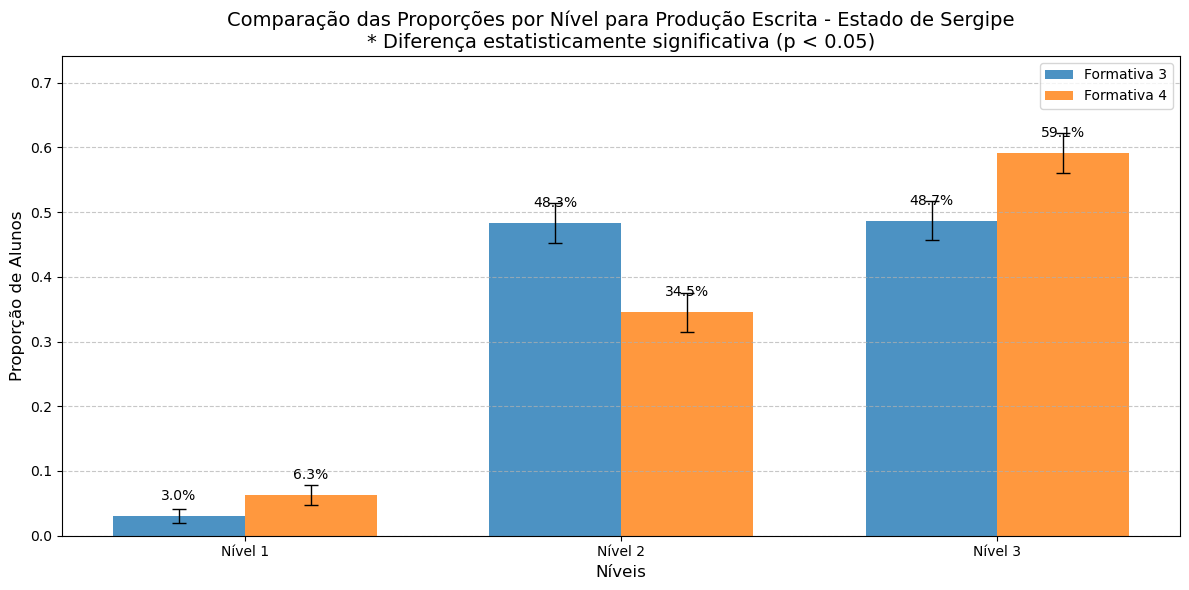

In [43]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_producao_escrita[f'prop_form_3_{nivel}'] = df_producao_escrita[f'form_3_{nivel}'] / df_producao_escrita['total_alunos_form_3']
    df_producao_escrita[f'prop_form_4_{nivel}'] = df_producao_escrita[f'form_4_{nivel}'] / df_producao_escrita['total_alunos_form_4']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO PRODUÇÃO ESCRITA PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_producao_escrita[f'prop_form_3_{nivel}'], 
                       df_producao_escrita[f'prop_form_4_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_producao_escrita[f'prop_form_4_{nivel}'] - df_producao_escrita[f'prop_form_3_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO PRODUÇÃO ESCRITA POR MUNICÍPIO ===\n")

for municipio in df_producao_escrita['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_producao_escrita[df_producao_escrita['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_3_{nivel}'], 
                           df_municipio[f'prop_form_4_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_4_{nivel}'] - df_municipio[f'prop_form_3_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA PRODUÇÃO ESCRITA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_3_Nível 1': df_producao_escrita['form_3_Nível 1'].sum(),
    'form_3_Nível 2': df_producao_escrita['form_3_Nível 2'].sum(),
    'form_3_Nível 3': df_producao_escrita['form_3_Nível 3'].sum(),
    'form_4_Nível 1': df_producao_escrita['form_4_Nível 1'].sum(),
    'form_4_Nível 2': df_producao_escrita['form_4_Nível 2'].sum(),
    'form_4_Nível 3': df_producao_escrita['form_4_Nível 3'].sum(),
    'total_form_3': df_producao_escrita['total_alunos_form_3'].sum(),
    'total_form_4': df_producao_escrita['total_alunos_form_4'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_3 e form_4:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_3_Nível 1'], totais_estado['form_3_Nível 2'], totais_estado['form_3_Nível 3']],
    [totais_estado['form_4_Nível 1'], totais_estado['form_4_Nível 2'], totais_estado['form_4_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_3 = [totais_estado['form_3_Nível 1']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 2']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 3']/totais_estado['total_form_3']]

prop_form_4 = [totais_estado['form_4_Nível 1']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 2']/totais_estado['total_form_4'],
               totais_estado['form_4_Nível 3']/totais_estado['total_form_4']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_3 = [calc_erro_proporcao(p, totais_estado['total_form_3']) for p in prop_form_3]
erro_form_4 = [calc_erro_proporcao(p, totais_estado['total_form_4']) for p in prop_form_4]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_3, bar_width, label='Formativa 3', alpha=0.8, color='#1f77b4',
               yerr=erro_form_3, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_4, bar_width, label='Formativa 4', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_4, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_producao_escrita[f'prop_form_3_{nivel}'], 
                            df_producao_escrita[f'prop_form_4_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_3[i], prop_form_4[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Produção Escrita - Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_3 + prop_form_4) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_producao_escrita_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [44]:
# Testando Produção Escrita e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_3_Nível 1': group['form_3_Nível 1'].sum(),
            'form_3_Nível 2': group['form_3_Nível 2'].sum(),
            'form_3_Nível 3': group['form_3_Nível 3'].sum(),
            'form_4_Nível 1': group['form_4_Nível 1'].sum(),
            'form_4_Nível 2': group['form_4_Nível 2'].sum(),
            'form_4_Nível 3': group['form_4_Nível 3'].sum(),
            'total_form_3': group['total_alunos_form_3'].sum(),
            'total_form_4': group['total_alunos_form_4'].sum()
        }
        
        # Calcular proporções
        prop_form_3 = [
            totais_municipio['form_3_Nível 1']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 2']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 3']/totais_municipio['total_form_3']
        ]
        
        prop_form_4 = [
            totais_municipio['form_4_Nível 1']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 2']/totais_municipio['total_form_4'],
            totais_municipio['form_4_Nível 3']/totais_municipio['total_form_4']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_3 = [calc_erro(p, totais_municipio['total_form_3']) for p in prop_form_3]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_4']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_3, bar_width, label='Formativa 3', color='#1f77b4',
                       yerr=erro_form_3, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 4', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_3_{nivel}'], 
                                        group[f'prop_form_4_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_3[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Produção Escrita - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_producao_escrita_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_producao_escrita, output_dir_relatorio_22)


Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Monte_Alegre_de_Sergipe.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Neópolis.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Pacatuba.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Poço_Verde.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Propriá.png


/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Gráfico salvo em: Data_files/graficos_relatorio_2.2/teste_wilcoxon_producao_escrita_Simão_Dias.png
